c:\Users\DELL\Desktop\TT\proyecto-transformacion-texto-imagen\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


F1-Test  Embeddings originales (768d): 0.7361
F1-Test  Componentes UMAP      (5d):   0.7246
Retención de capacidad discriminativa: 98.4%


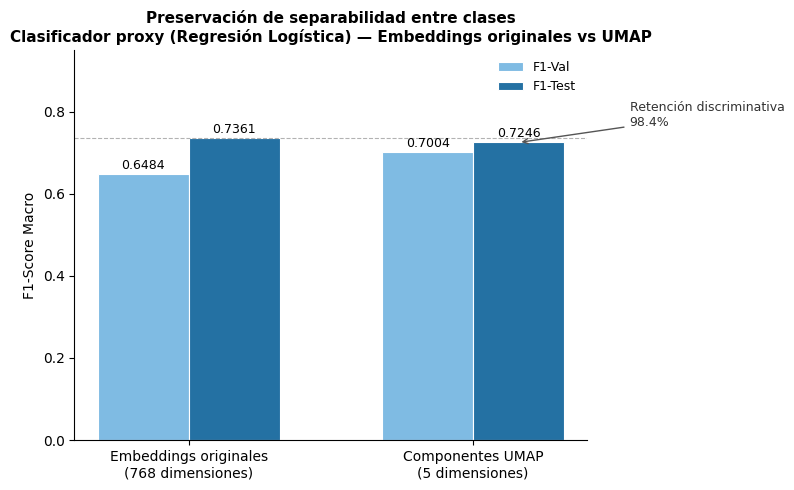

In [1]:
# ============================================================
# ANÁLISIS 1: Preservación de separabilidad — Clasificador proxy
# Compara F1-Macro con embeddings originales vs componentes UMAP
# ============================================================
import joblib, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


pkg    = joblib.load(f'../models/best_model/Exp_4.1_BETO_HPO_embeddings.pkl')
shared = joblib.load(f'../data/shared/umap_params.pkl')

# ── Datos originales (768 dims) ──────────────────────────────
X_tr_orig = pkg['X_train'];  y_tr = pkg['y_train']
X_val_orig = pkg['X_val'];   y_val = pkg['y_val']
X_te_orig = pkg['X_test'];   y_te = pkg['y_test']

# ── Componentes UMAP normalizados (5 dims) ───────────────────
X_tr_umap  = shared['train']['params']
X_val_umap = shared['val']['params']
X_te_umap  = shared['test']['params']

# ── Clasificador proxy idéntico para ambos espacios ──────────
def evaluar(X_tr, X_te, y_tr, y_te, nombre):
    clf = LogisticRegression(
        class_weight='balanced', solver='liblinear',
        random_state=42, max_iter=1000
    )
    clf.fit(X_tr, y_tr)
    f1_val = f1_score(y_val, clf.predict(X_val_umap if 'UMAP' in nombre else X_val_orig),
                      average='macro')
    f1_te  = f1_score(y_te, clf.predict(X_te), average='macro')
    return f1_val, f1_te

f1_val_orig, f1_te_orig = evaluar(X_tr_orig, X_te_orig, y_tr, y_te, 'Original')
f1_val_umap, f1_te_umap = evaluar(X_tr_umap, X_te_umap, y_tr, y_te, 'UMAP')

retencion = (f1_te_umap / f1_te_orig) * 100

print(f"F1-Test  Embeddings originales (768d): {f1_te_orig:.4f}")
print(f"F1-Test  Componentes UMAP      (5d):   {f1_te_umap:.4f}")
print(f"Retención de capacidad discriminativa: {retencion:.1f}%")

# ── Gráfica de barras comparativa ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

etiquetas  = ['Embeddings originales\n(768 dimensiones)',
               'Componentes UMAP\n(5 dimensiones)']
valores_val  = [f1_val_orig, f1_val_umap]
valores_test = [f1_te_orig,  f1_te_umap]

x = np.arange(len(etiquetas))
w = 0.32

barras_val  = ax.bar(x - w/2, valores_val,  width=w, color='#7fbbe3',
                     edgecolor='white', linewidth=0.8, label='F1-Val')
barras_test = ax.bar(x + w/2, valores_test, width=w, color='#2471a3',
                     edgecolor='white', linewidth=0.8, label='F1-Test')

# Etiquetas de valor
for b in list(barras_val) + list(barras_test):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9)

# Anotación de retención
ax.annotate(
    f'Retención discriminativa\n{retencion:.1f}%',
    xy=(1 + w/2, f1_te_umap), xytext=(1.55, f1_te_umap + 0.04),
    arrowprops=dict(arrowstyle='->', color='#555'),
    fontsize=9, color='#333'
)

ax.set_ylim(0, 0.95)
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=10)
ax.set_ylabel('F1-Score Macro', fontsize=10)
ax.set_title(
    'Preservación de separabilidad entre clases\n'
    'Clasificador proxy (Regresión Logística) — Embeddings originales vs UMAP',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.axhline(f1_te_orig, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(f'../results/umap_retencion_discriminativa.png',
            dpi=150, bbox_inches='tight')
plt.show()